# Importar Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")

# 1. Cargar el conjunto de datos en una estructura adecuada para su manipulación.

In [2]:
df_autos = pd.read_csv("Automobile.csv", encoding = "UTF-8")
df_autos.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


## Descripción de los datos
mpg: Millas por galón (consumo de combustible)

cylinders: Cilindros en el motor

displacement: Desplazamiento del motor (en pulgadas cúbicas)

horsepower: Potencia del motor (caballos de fuerza)

weight: Peso del automóvil

acceleration: Aceleración (0-60 mph en segundos)

model_year: Año del modelo (ej. 70 representa 1970)

origin: Origen del automóvil (1: Estados Unidos, 2: Europa, 3: Asia)

In [3]:
print("\n--- Información general ---")
df_autos.info()


--- Información general ---
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    str    
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


In [4]:
print("\n--- Estadísticas descriptivas — variables numéricas ---")
df_autos.describe()


--- Estadísticas descriptivas — variables numéricas ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


# 2. Crear un gráfico de dispersión para visualizar las relaciones entre los pares de características numéricas mpg y weight.

In [5]:
# Matriz de correlación
print("\n--- Correlaciones ---")
# Utilizamos sólo las variables numéricas de interés
cols_numericas = ['mpg', 'weight']
corr = df_autos[cols_numericas].corr()

print(corr.round(2))


--- Correlaciones ---
         mpg  weight
mpg     1.00   -0.83
weight -0.83    1.00


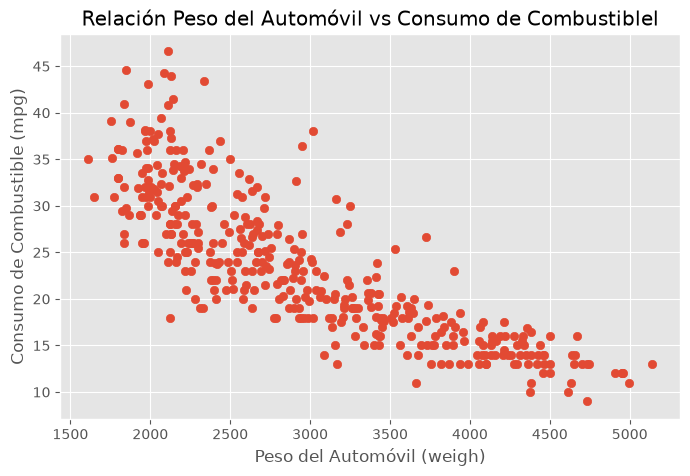

In [6]:
# Scatterplots
plt.scatter(df_autos["weight"], df_autos["mpg"])
plt.xlabel("Peso del Automóvil (weigh)")
plt.ylabel("Consumo de Combustible (mpg)")
plt.title("Relación Peso del Automóvil vs Consumo de Combustiblel")
plt.show()

###  Se observa una tendencia descendente clara → a mayor peso del automóvil, menor rendimiento del combustible.

# 3. Generar un histograma del consumo de combustible (mpg) para analizar su distribución.

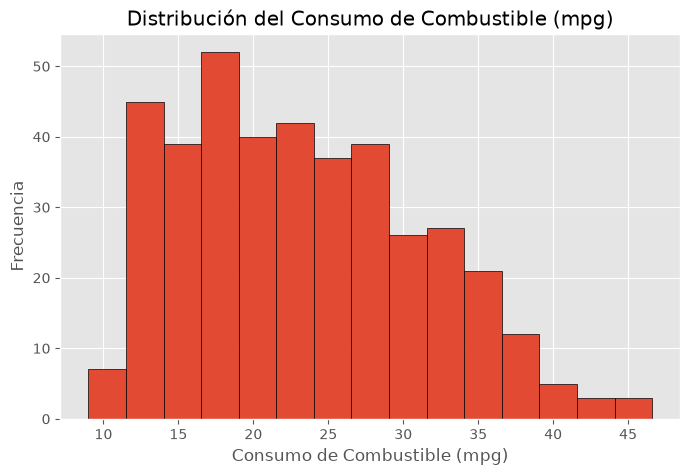

In [7]:
plt.hist(df_autos["mpg"], bins=15, edgecolor="black")

plt.title("Distribución del Consumo de Combustible (mpg)")
plt.xlabel("Consumo de Combustible (mpg)")
plt.ylabel("Frecuencia")

plt.show()

# 4. Graficar un diagrama de caja (boxplot) de las características cylinders y origin para identificar posibles valores atípicos.

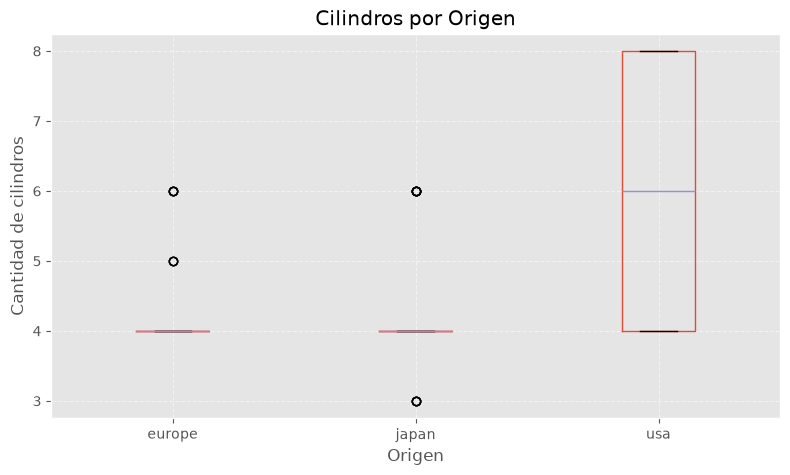

In [8]:
df_autos.boxplot(column='cylinders', by='origin')
plt.title('Cilindros por Origen')
plt.suptitle('')  # quita el título automático de pandas
plt.xlabel('Origen')
plt.ylabel('Cantidad de cilindros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Observaciones:

Europa: la mayoría tiene 4 cilindros, con algunos casos de 5 y 6.

Japon: casi todos tienen 4 cilindros, con algunos casos de 3 y 6.

USA: mayoría 8 cilindros, algunos 4 y 6.

In [9]:
Q1 = df_autos["cylinders"].quantile(0.25)
Q3 = df_autos["cylinders"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

outliers = df_autos[(df_autos["cylinders"] < Q1 - 1.5*IQR) | (df_autos["cylinders"] > Q3 + 1.5*IQR)]

print(f"\nCantidad de outliers en Cantidad de Cilindros: {len(outliers)}")
print(outliers)

Q1 = 4.0
Q3 = 8.0
IQR = 4.0

Cantidad de outliers en Cantidad de Cilindros: 0
Empty DataFrame
Columns: [name, mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin]
Index: []


# 5. Realizar un gráfico de barras que muestre la distribución de automóviles según su año de modelo (model_year) y origen (origin).

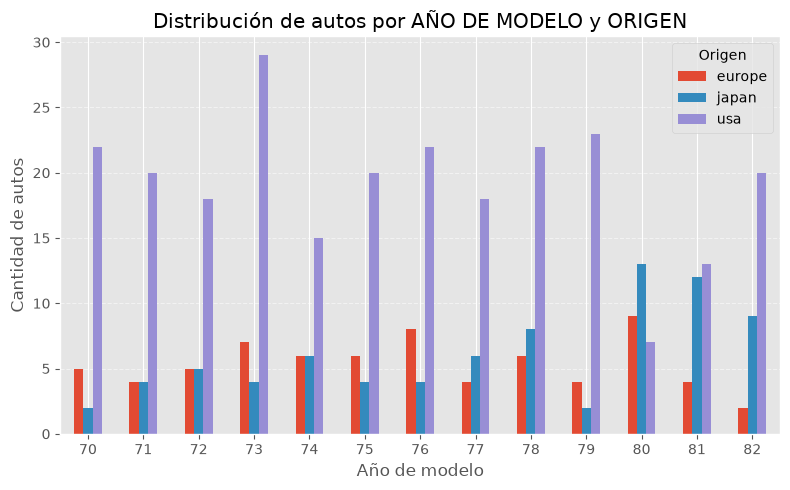

In [10]:
# Contar registros por año y origen
df_autos.groupby(["model_year", "origin"]).size().unstack(fill_value=0).plot(kind="bar")

plt.title("Distribución de autos por AÑO DE MODELO y ORIGEN")
plt.xlabel("Año de modelo")
plt.ylabel("Cantidad de autos")
plt.legend(title="Origen")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Entre 1970–72 predominan los autos estadounidenses grandes de 8 cilindros; entre 1973–76, Japon y Europa ganan terreno y entre 1977–82 crecen fuertemente, mientras USA pierde teerreno.

## Recuerda que la visualización de datos es una etapa esencial en el proceso de Aprendizaje Automático, ya que proporciona intuiciones valiosas que pueden guiar decisiones posteriores en la construcción y evaluación de modelos predictivos. Utiliza Matplotlib para crear gráficos claros y etiquetados que ayuden en el análisis de los datos.